# Analysis of nuclide and flux relaxation in RM schemes

In [ ]:
import CustomSchemes
from CustomSchemes import SIE
from CustomSchemes.SIE import load_SIE as load_SIE
import matplotlib.pyplot as plt

In [ ]:
the_file = SIE.SIE().get_from_pkl("FLUX.pkl")

In [ ]:
the_file.plot_all_x()

In [ ]:
plt.figure(figsize=(5,3))
for this in the_file.get_x_by_iteration(time=325):
  plt.plot(this)
CustomSchemes.Colors.nice_grid()
CustomSchemes.Colors.nice_legend()

In [ ]:
plt.figure(figsize=(5,3))
for this in the_file.get_fx_by_iteration(time=325):
  plt.plot(this)
CustomSchemes.Colors.nice_grid()
CustomSchemes.Colors.nice_legend()

In [ ]:
the_file.x[0.0][0]


# Anderson Acceleration analysis

In [ ]:
from CustomSchemes.AA import Anderson as Anderson
import matplotlib.pyplot as plt
aa = Anderson().get_from_pkl('aa2_i4_t3.pkl')

In [ ]:
time = 3.0
for this in aa.fx[time]:
  plt.plot(this)

In [ ]:
aa.get

In [ ]:
from CustomSchemes.aa_validator import validate_case
validate_case(time=3.0, file='aa2_i4_t3.pkl', k_max=4, m=2, dpi=100)

# Visual comparison of each

In [ ]:
from CustomSchemes.AA import Anderson as Anderson
from CustomSchemes.SIE import SIE as SIE
import matplotlib.pyplot as plt
from CustomSchemes.Colors import Colors
from CustomSchemes.Colors import nice_grid, nice_legend
import numpy as np
clrs = Colors.colors2()
aa = Anderson().get_from_pkl('aa2_i4_t3.pkl')
flux = SIE().get_from_pkl('FLUX.pkl')
nuclide = SIE().get_from_pkl('NUCLIDE.pkl')


In [ ]:
def difference(x, ref) -> np.ndarray:
  return np.array([1-x[idx]/ref[idx] for idx in range(len(ref))])

time = 0.5
plt.figure(figsize=(5,3), dpi=250)
plt.plot(flux.x[time][-1], 's-', markerfacecolor='none', color=clrs[0], label=r'$SIE_{\phi}$', lw=0.5)
plt.plot(nuclide.x[time][-1], 'o-', markerfacecolor='none', color=clrs[1], label='$SIE_{N}$', lw=0.5)
plt.plot(aa.x[time][-1], 'x-', markerfacecolor='none', color=clrs[2], label='AA', lw=0.5)
nice_legend()
nice_grid()

time = 0.5
ref = flux.x[time][-1]
aa_x = aa.x[time][-1]
nuc_x = nuclide.x[time][-1]

plt.figure(figsize=(5,3), dpi=250)
plt.plot(difference(ref, ref), 's-', markerfacecolor='none', color=clrs[0], label=r'$SIE_{\phi}$', lw=0.5)
plt.plot(difference(nuc_x, ref), 'o-', markerfacecolor='none', color=clrs[1], label='$SIE_{N}$', lw=0.5)
plt.plot(difference(aa_x, ref), 'x-', markerfacecolor='none', color=clrs[2], label='AA', lw=0.5)
nice_legend()
nice_grid()


# Results for a single step

In [3]:
from CustomSchemes.AA import Anderson as Anderson
from CustomSchemes.SIE import SIE as SIE
import matplotlib.pyplot as plt
from CustomSchemes.Colors import Colors
from CustomSchemes.Colors import nice_grid, nice_legend
import matplotlib.pyplot as plt
import numpy as np
clrs = Colors.colors2()
aa = Anderson().get_from_pkl('aa2_i100_t2.pkl')
aaScaling = Anderson().get_from_pkl('aa2_scaling1.5_1step.pkl')


from CustomSchemes.DumbTransport import flat_transport

x = aa.get_x_by_iteration(time=325.0)

/tmp/ipykernel_4861/966328988.py:38: RuntimeWarning: divide by zero encountered in divide
  plt.plot(histories_scaling   ,    resids_xscaling[1] * histories_scaling[1]**0.5 / np.array(histories_scaling)**0.5, 'k--')


(None, None)

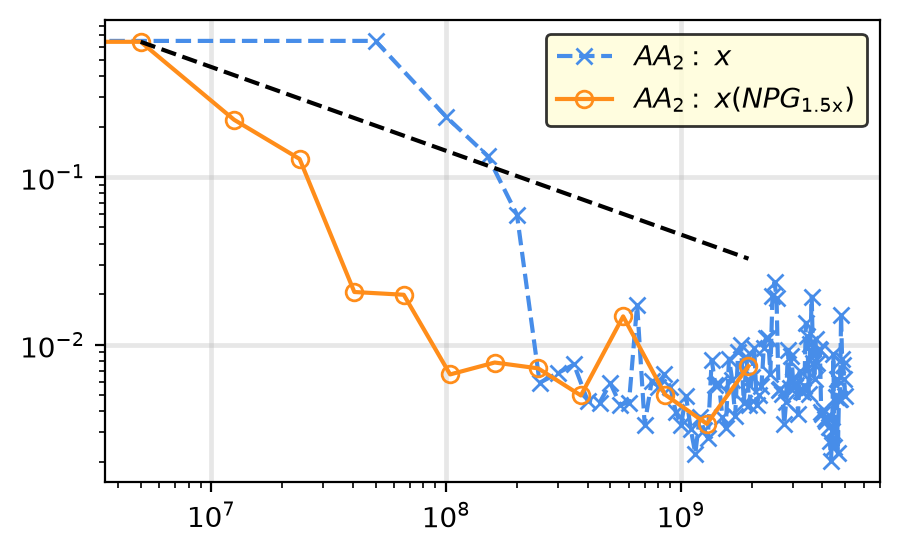

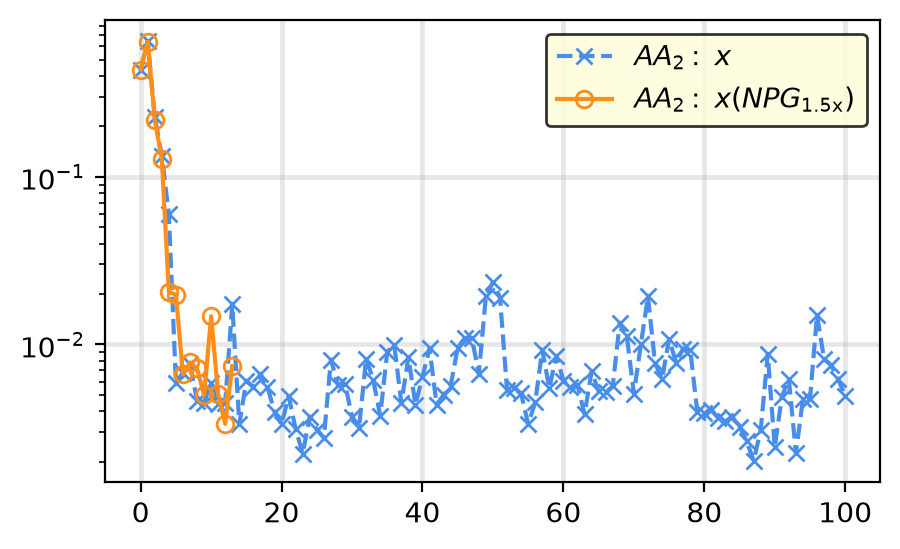

In [ ]:
def get_norm(x: np.ndarray, xref: np.ndarray, order: int = 2) -> float:
  return (np.linalg.norm(x - xref, ord=order)/np.linalg.norm(x, ord=order))

ref = flat_transport(16)
x = aa.get_x_by_iteration(time=325.0)
fx = aa.get_fx_by_iteration(time=325.0)
xscaling = aaScaling.get_x_by_iteration(time=325.0)


resids_x = []
resids_fx = []
resids_xscaling = []
total_histories = []


npg = 0
for idx, this in enumerate(x):
  resids_x.append(get_norm(this, ref))
  total_histories.append(npg)
  try:
    npg+=100000*500
  except:
    npg += 0

npg = 0
histories_scaling = [0]
for idx, this in enumerate(xscaling):
  resids_xscaling.append(get_norm(this, ref))
for idx, this in enumerate(aaScaling._npg[325]):
  histories_scaling.append(histories_scaling[-1] + aaScaling._npg[325.0][idx]*500)



plt.figure(figsize=(5,3), dpi=200)
plt.plot(total_histories, resids_x, 'x--', label=r'$AA_2:$ $x$', markerfacecolor='none', color=Colors.colors2()[0])
# plt.plot(total_histories, resids_fx, 'kx--', label=r'$AA2:$ $f(x)$')
plt.plot(histories_scaling,resids_xscaling , 'o-', label=r'$AA_2:$ $x(NPG_{1.5\mathrm{x}})$', markerfacecolor='none', color=Colors.colors2()[1])
plt.plot(histories_scaling   ,    resids_xscaling[1] * histories_scaling[1]**0.5 / np.array(histories_scaling)**0.5, 'k--')
plt.yscale('log')
plt.xscale('log')
nice_grid(), nice_legend()




plt.figure(figsize=(5,3), dpi=200)
plt.plot(resids_x, 'x--', label=r'$AA_2:$ $x$', markerfacecolor='none', color=Colors.colors2()[0])
# plt.plot(total_histories, resids_fx, 'kx--', label=r'$AA2:$ $f(x)$')
plt.plot(resids_xscaling , 'o-', label=r'$AA_2:$ $x(NPG_{1.5\mathrm{x}})$', markerfacecolor='none', color=Colors.colors2()[1])
plt.yscale('log')
# plt.xscale('log')
nice_grid(), nice_legend()

In [103]:
idx

13

In [110]:
len(aaScaling._npg[325])

13

In [ ]:
resids_xscaling[1], histories_scaling[1]

expected = resids_xscaling[1] * histories_scaling[1]**0.5 / np.array(histories_scaling)**0.5

/tmp/ipykernel_4861/1962507028.py:3: RuntimeWarning: divide by zero encountered in divide
  resids_xscaling[1] * histories_scaling[1]**0.5 / np.array(histories_scaling)**0.5


array([       inf, 0.64043658, 0.40504766, 0.29385246, 0.22468001,
       0.17635789, 0.14048818, 0.11291122, 0.09125102, 0.07400702,
       0.06015929, 0.04897603, 0.03991104, 0.03254512])

In [ ]:
from CustomSchemes.aa_validator import validate_case
validate_case(time=325.0, file='aa2_i100_t2.pkl', k_max=100, m=2, dpi=100)

In [118]:
# Input these parameters to see how many solves are needed to reach a total NPG
factor = 1.5
starting_npg = 10000
nactive = 500

test = np.linspace(starting_npg, starting_npg,100)
for idx in range(len(test)):
  test[idx] = factor**idx * test[idx]
  print(f"at {idx+1} solves, the sum is { sum(test[0:idx+1]) / 1e11 * nactive } e11")


at 1 solves, the sum is 4.9999999999999996e-05 e11
at 2 solves, the sum is 0.000125 e11
at 3 solves, the sum is 0.0002375 e11
at 4 solves, the sum is 0.00040625 e11
at 5 solves, the sum is 0.000659375 e11
at 6 solves, the sum is 0.0010390625 e11
at 7 solves, the sum is 0.00160859375 e11
at 8 solves, the sum is 0.002462890625 e11
at 9 solves, the sum is 0.0037443359375 e11
at 10 solves, the sum is 0.00566650390625 e11
at 11 solves, the sum is 0.008549755859375 e11
at 12 solves, the sum is 0.0128746337890625 e11
at 13 solves, the sum is 0.01936195068359375 e11
at 14 solves, the sum is 0.029092926025390625 e11
at 15 solves, the sum is 0.04368938903808594 e11
at 16 solves, the sum is 0.06558408355712891 e11
at 17 solves, the sum is 0.09842612533569335 e11
at 18 solves, the sum is 0.14768918800354003 e11
at 19 solves, the sum is 0.22158378200531006 e11
at 20 solves, the sum is 0.33242567300796505 e11
at 21 solves, the sum is 0.49868850951194765 e11
at 22 solves, the sum is 0.748082764267921

In [99]:
test

array([1.00000000e+04, 1.50000000e+04, 2.25000000e+04, 3.37500000e+04,
       5.06250000e+04, 7.59375000e+04, 1.13906250e+05, 1.70859375e+05,
       2.56289062e+05, 3.84433594e+05, 5.76650391e+05, 8.64975586e+05,
       1.29746338e+06, 1.94619507e+06, 2.91929260e+06, 4.37893890e+06,
       6.56840836e+06, 9.85261253e+06, 1.47789188e+07, 2.21683782e+07,
       3.32525673e+07, 4.98788510e+07, 7.48182764e+07, 1.12227415e+08,
       1.68341122e+08, 2.52511683e+08, 3.78767524e+08, 5.68151287e+08,
       8.52226930e+08, 1.27834039e+09, 1.91751059e+09, 2.87626589e+09,
       4.31439883e+09, 6.47159825e+09, 9.70739737e+09, 1.45610961e+10,
       2.18416441e+10, 3.27624661e+10, 4.91436992e+10, 7.37155488e+10,
       1.10573323e+11, 1.65859985e+11, 2.48789977e+11, 3.73184966e+11,
       5.59777449e+11, 8.39666173e+11, 1.25949926e+12, 1.88924889e+12,
       2.83387333e+12, 4.25081000e+12, 6.37621500e+12, 9.56432250e+12,
       1.43464838e+13, 2.15197256e+13, 3.22795884e+13, 4.84193827e+13,
      

In [90]:
sum(aaScaling._npg[325])*500 / 1e11

0.01936201

In [101]:
sum(aaScaling._npg[325]) * 500

1936201000

In [97]:
aaScaling.fx[325].__len__()

13